# Milestone 0 — Data Preparation & EDA
**Smart Product Intelligence | All_Beauty | Kaggle**

## ⚠️ STEP 1: Run this cell FIRST, then Restart & Run All

In [1]:
!pip install -q "datasets==2.19.0"
print('\n✅ Done! Now click: Run → Restart & Run All')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you have numba-cuda 0.30.2 which is incompatible.
torch 2.10.0+cu128 requires cuda-bindings==12.9.4; platform_system == "Linux", but you have cuda-bindings 13.2.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fssp

## 1. Imports & Setup

In [2]:
import os, requests, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
Path('data').mkdir(exist_ok=True)
Path('data/images').mkdir(exist_ok=True)
Path('data/splits').mkdir(exist_ok=True)
print('✅ Setup complete.')

✅ Setup complete.


## 2. Load Dataset

In [3]:
print('Loading reviews...')
reviews_ds = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_review_All_Beauty',
    split='full',
    trust_remote_code=True
)
print(f'✅ Reviews: {len(reviews_ds):,} rows')

Loading reviews...


Generating full split: 0 examples [00:00, ? examples/s]

✅ Reviews: 701,528 rows


In [4]:
print('Loading metadata...')
meta_ds = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_meta_All_Beauty',
    split='full',
    trust_remote_code=True
)
print(f'✅ Metadata: {len(meta_ds):,} rows')

Loading metadata...


Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

✅ Metadata: 112,590 rows


## 3. Convert to DataFrames

In [5]:
reviews_df = reviews_ds.to_pandas()
meta_df    = meta_ds.to_pandas()
print('Reviews shape:', reviews_df.shape)
print('Meta shape   :', meta_df.shape)
reviews_df.head(2)

Reviews shape: (701528, 10)
Meta shape   : (112590, 16)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True


## 4. Clean Metadata

In [6]:
meta_clean = meta_df[[
    'parent_asin','title','average_rating','rating_number',
    'price','store','categories','features','description','images'
]].copy()

meta_clean['price'] = (
    meta_clean['price'].astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
    .replace('', np.nan).astype(float)
)
meta_clean = meta_clean.drop_duplicates(subset='parent_asin', keep='first')

def extract_image_url(images_dict):
    try:
        for key in ['hi_res', 'large']:
            for url in (images_dict.get(key) or []):
                if url and str(url) != 'None':
                    return url
    except:
        pass
    return None

meta_clean['image_url'] = meta_clean['images'].apply(extract_image_url)
print(f'✅ Unique products : {len(meta_clean):,}')
print(f'✅ With image URL  : {meta_clean["image_url"].notna().sum():,}')

✅ Unique products : 112,590
✅ With image URL  : 24,397


## 5. Clean Reviews

In [7]:
reviews_clean = reviews_df[[
    'parent_asin','rating','title','text','helpful_vote','verified_purchase','timestamp'
]].copy()
reviews_clean = reviews_clean.dropna(subset=['text','rating'])
reviews_clean['review_length'] = reviews_clean['text'].str.split().str.len()

valid_asins   = set(meta_clean['parent_asin'])
reviews_clean = reviews_clean[reviews_clean['parent_asin'].isin(valid_asins)]
print(f'✅ Reviews : {len(reviews_clean):,}')
print(f'✅ Products: {reviews_clean["parent_asin"].nunique():,}')

✅ Reviews : 701,528
✅ Products: 112,565


## 6. Subsample

In [8]:
# Keep products with >= 3 reviews
counts       = reviews_clean['parent_asin'].value_counts()
active       = counts[counts >= 3].index
reviews_clean = reviews_clean[reviews_clean['parent_asin'].isin(active)]
meta_clean    = meta_clean[meta_clean['parent_asin'].isin(active)]

# Cap at 15k products
MAX_PRODUCTS = 15_000
if meta_clean['parent_asin'].nunique() > MAX_PRODUCTS:
    keep = meta_clean['parent_asin'].sample(MAX_PRODUCTS, random_state=SEED).values
    meta_clean    = meta_clean[meta_clean['parent_asin'].isin(keep)]
    reviews_clean = reviews_clean[reviews_clean['parent_asin'].isin(keep)]

print(f'✅ Final products: {meta_clean["parent_asin"].nunique():,}')
print(f'✅ Final reviews : {len(reviews_clean):,}')

✅ Final products: 15,000
✅ Final reviews : 198,468


## 7. Split by Product (no leakage)

In [9]:
all_asins = meta_clean['parent_asin'].unique()
train_asins, temp       = train_test_split(all_asins, test_size=0.30, random_state=SEED)
val_asins,   test_asins = train_test_split(temp,      test_size=0.50, random_state=SEED)

pd.Series(train_asins).to_csv('data/splits/train_asins.csv', index=False)
pd.Series(val_asins).to_csv('data/splits/val_asins.csv',     index=False)
pd.Series(test_asins).to_csv('data/splits/test_asins.csv',   index=False)
print(f'✅ Train: {len(train_asins):,} | Val: {len(val_asins):,} | Test: {len(test_asins):,}')

✅ Train: 10,500 | Val: 2,250 | Test: 2,250


## 8. Save DataFrames

In [10]:
meta_clean.to_parquet('data/meta_clean.parquet',       index=False)
reviews_clean.to_parquet('data/reviews_clean.parquet', index=False)
print('✅ Saved meta_clean.parquet and reviews_clean.parquet')

✅ Saved meta_clean.parquet and reviews_clean.parquet


## 9. Download Product Images

In [11]:
MAX_IMAGES = 8000
pool = meta_clean[meta_clean['image_url'].notna()]
pool = pool.sample(min(MAX_IMAGES, len(pool)), random_state=SEED)

success, failed = 0, 0
for _, row in tqdm(pool.iterrows(), total=len(pool), desc='Images'):
    path = Path(f'data/images/{row["parent_asin"]}.jpg')
    if path.exists():
        success += 1; continue
    try:
        r   = requests.get(row['image_url'], timeout=8)
        img = Image.open(BytesIO(r.content)).convert('RGB').resize((224,224))
        img.save(path, 'JPEG', quality=85)
        success += 1
    except:
        failed += 1

print(f'✅ Downloaded: {success:,} | Failed: {failed:,}')

Images:   0%|          | 0/2853 [00:00<?, ?it/s]

✅ Downloaded: 2,853 | Failed: 0


## 10. EDA Plots

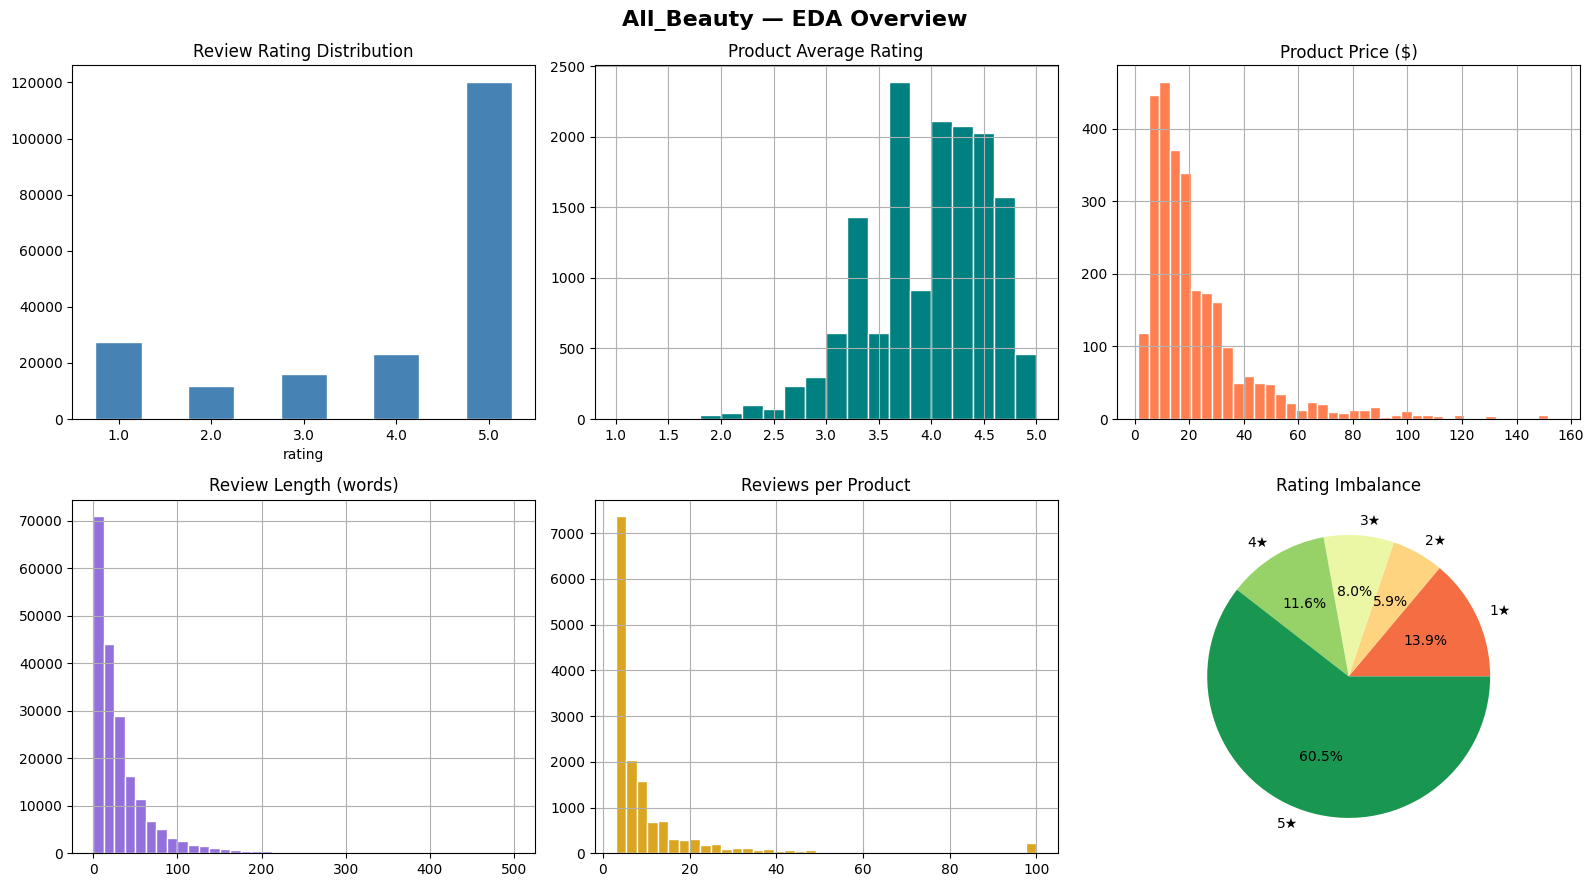

✅ EDA plot saved.


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('All_Beauty — EDA Overview', fontsize=16, fontweight='bold')

reviews_clean['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Review Rating Distribution')
axes[0,0].tick_params(axis='x', rotation=0)

meta_clean['average_rating'].dropna().hist(
    bins=20, ax=axes[0,1], color='teal', edgecolor='white')
axes[0,1].set_title('Product Average Rating')

prices = meta_clean['price'].dropna()
prices[prices < prices.quantile(0.99)].hist(
    bins=40, ax=axes[0,2], color='coral', edgecolor='white')
axes[0,2].set_title('Product Price ($)')

reviews_clean['review_length'].clip(upper=500).hist(
    bins=40, ax=axes[1,0], color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Review Length (words)')

reviews_clean.groupby('parent_asin').size().clip(upper=100).hist(
    bins=40, ax=axes[1,1], color='goldenrod', edgecolor='white')
axes[1,1].set_title('Reviews per Product')

rc = reviews_clean['rating'].value_counts().sort_index()
axes[1,2].pie(rc, labels=[f'{int(r)}★' for r in rc.index],
    autopct='%1.1f%%', colors=plt.cm.RdYlGn(np.linspace(0.2,0.9,5)))
axes[1,2].set_title('Rating Imbalance')

plt.tight_layout()
plt.savefig('data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plot saved.')

## 11. Missing Data Report

In [13]:
print('=== METADATA ===')
m = meta_clean.isnull().sum()
print(pd.DataFrame({'missing':m,'pct%':(m/len(meta_clean)*100).round(1)})[m>0].to_string())
print('\n=== REVIEWS ===')
r = reviews_clean.isnull().sum()
print(pd.DataFrame({'missing':r,'pct%':(r/len(reviews_clean)*100).round(1)})[r>0].to_string())

=== METADATA ===
           missing  pct%
price        12190  81.3
store         1170   7.8
image_url    12147  81.0

=== REVIEWS ===
Empty DataFrame
Columns: [missing, pct%]
Index: []


## 12. Final Summary

In [14]:
cached = len(list(Path('data/images').glob('*.jpg')))
print('=' * 45)
print('       MILESTONE 0 SUMMARY')
print('=' * 45)
print(f'  Unique products      : {meta_clean["parent_asin"].nunique():>8,}')
print(f'  Total reviews        : {len(reviews_clean):>8,}')
print(f'  Cached images        : {cached:>8,}')
print(f'  Median price         : ${meta_clean["price"].median():>7.2f}')
print(f'  Median review length : {reviews_clean["review_length"].median():>5.0f} words')
print(f'  5-star share         : {(reviews_clean["rating"]==5).mean()*100:>6.1f}%')
print(f'  Train/Val/Test       : {len(train_asins):,} / {len(val_asins):,} / {len(test_asins):,}')
print('=' * 45)
print('  ✅ Ready for Milestone 1!')

       MILESTONE 0 SUMMARY
  Unique products      :   15,000
  Total reviews        :  198,468
  Cached images        :    2,853
  Median price         : $  16.95
  Median review length :    20 words
  5-star share         :   60.5%
  Train/Val/Test       : 10,500 / 2,250 / 2,250
  ✅ Ready for Milestone 1!
